<h2>Step 1: Import Libraries</h2>

In [1]:
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

<h2>Step 2: Import Raw Data</h2>

In [2]:
master_df = pd.read_csv("Nomura Rates PCA Data.csv")
master_df

,Dates,USGG3M Index,USGG2YR Index,USGG5YR Index,USGG10YR Index,USGG30YR Index
0,1/1/2015,0.0355,0.6645,1.6528,2.1712,2.7518
1,1/2/2015,0.0152,0.6647,1.6070,2.1105,2.6880
2,1/5/2015,0.0101,0.6568,1.5645,2.0320,2.5987
3,1/6/2015,0.0253,0.6250,1.4780,1.9402,2.5023
4,1/7/2015,0.0203,0.6091,1.4779,1.9677,2.5289
...,...,...,...,...,...,...
2852,12/8/2025,3.6946,3.5750,3.7463,4.1643,4.8019
2853,12/9/2025,3.7020,3.6147,3.7867,4.1878,4.8080
2854,12/10/2025,3.6655,3.5381,3.7308,4.1468,4.7868
2855,12/11/2025,3.6419,3.5404,3.7344,4.1566,4.7999


<h2>Step 3: Create a new array based on raw data</h2>

In [3]:
maturities_anchors = np.array([0.25, 2, 10, 30]) 
target_maturity = 5
dates, actual_5y, fair_5y = [], [], []

<h2>Step 4: Fit a cubic spline curve on the raw data</h2>

In [4]:
for index, row in master_df.iterrows():
    y_anchors = row[['USGG3M Index','USGG2YR Index','USGG10YR Index','USGG30YR Index']].values
    cs = CubicSpline(maturities_anchors, y_anchors, bc_type='natural')
    dates.append(row['Dates'])
    actual_5y.append(row['USGG5YR Index'])
    fair_5y.append(cs(target_maturity))

<h2>Step 5: Align all arrays and dataframes, calculate Z-spread</h2>

In [5]:
min_length = min(len(dates), len(actual_5y), len(fair_5y))
dates = dates[:min_length]
actual_5y = actual_5y[:min_length]
fair_5y = fair_5y[:min_length]

res = pd.DataFrame({'Date': dates, 'Actual': actual_5y, 'Fair': fair_5y})
res['Spread'] = res['Actual'] - res['Fair']
window = 126
res['Z_Score'] = (res['Spread'] - res['Spread'].rolling(window).mean()) / res['Spread'].rolling(window).std()

<h2>Step 6: Clean all arrays and dataframes and plot the charts</h2>

C:\Users\siddh\AppData\Local\Temp\ipykernel_11492\2696263377.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['Date'] = pd.to_datetime(plot_data['Date'])
C:\Users\siddh\AppData\Local\Temp\ipykernel_11492\2696263377.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data[col] = pd.to_numeric(plot_data[col], errors='coerce')


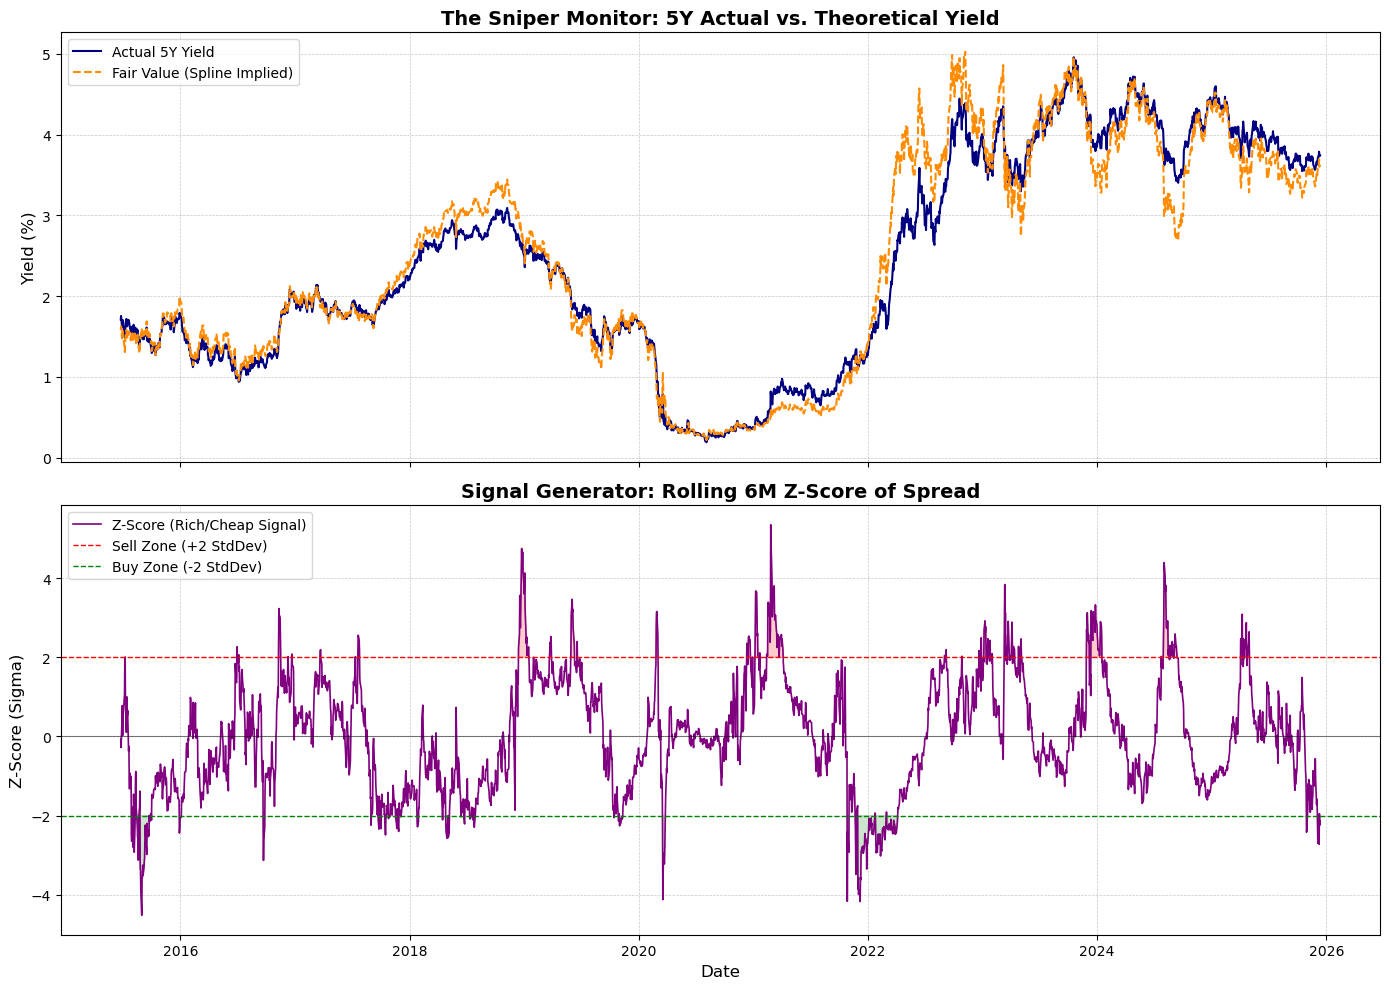

In [6]:
plot_data = res.dropna()

plot_data['Date'] = pd.to_datetime(plot_data['Date'])

numeric_columns = ['Actual', 'Fair', 'Z_Score']
for col in numeric_columns:
    plot_data[col] = pd.to_numeric(plot_data[col], errors='coerce')

plot_data = plot_data.dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(plot_data['Date'], plot_data['Actual'], label='Actual 5Y Yield', color='navy', linewidth=1.5)
ax1.plot(plot_data['Date'], plot_data['Fair'], label='Fair Value (Spline Implied)', color='darkorange', linestyle='--', linewidth=1.5)

ax1.set_title('The Sniper Monitor: 5Y Actual vs. Theoretical Yield', fontsize=14, fontweight='bold')
ax1.set_ylabel('Yield (%)', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)

ax2.plot(plot_data['Date'], plot_data['Z_Score'], label='Z-Score (Rich/Cheap Signal)', color='purple', linewidth=1.2)

ax2.axhline(2.0, color='red', linestyle='--', linewidth=1, label='Sell Zone (+2 StdDev)')
ax2.axhline(-2.0, color='green', linestyle='--', linewidth=1, label='Buy Zone (-2 StdDev)')
ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5) 

ax2.fill_between(plot_data['Date'], plot_data['Z_Score'], 2, 
                 where=(plot_data['Z_Score'] >= 2), interpolate=True, color='red', alpha=0.2)

ax2.fill_between(plot_data['Date'], plot_data['Z_Score'], -2, 
                 where=(plot_data['Z_Score'] <= -2), interpolate=True, color='green', alpha=0.2)

ax2.set_title('Signal Generator: Rolling 6M Z-Score of Spread', fontsize=14, fontweight='bold')
ax2.set_ylabel('Z-Score (Sigma)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()

plt.savefig('Sniper_Rates_Fly_Monitor.png', dpi=300)
plt.show()